In [57]:
import torch
import torch.nn as nn
import torch.optim as optim

# parameters
M = 1
K = 400
B = 80

# initial conditions
X0 = 1
X_T_0 = 0

# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1)    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

# Define the Poisson equation loss function
def capacitor_charge_loss(model, t):
    x = model(t)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]
    f = (x_tt + (B/M)*x_t + (K/M)*x)**2  # Poisson equation: u_xx = 1
    t_0 = torch.tensor([0.0], requires_grad=True)
    x_0 = model(t_0)
    initial_conditions = (x_0 - X0)**2
    x_t_0 = torch.autograd.grad(x_0, t_0, grad_outputs=torch.ones_like(x_0), create_graph=True)[0]
    initial_conditions_der = (x_t_0 - X_T_0)**2
    return torch.mean(f) + torch.mean(initial_conditions) + torch.mean(initial_conditions_der)

# Training data
t = 10*torch.rand(100, 1)  # Randomly sampled points in [0, 1]
t.requires_grad = True

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=[{'params': model.parameters()}, {'params': t}], lr=1e-4)

# Training loop
epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = capacitor_charge_loss(model, t)
    
    # Backpropagation
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")

Epoch [0/10000], Loss: 955.7227783203125
Epoch [1000/10000], Loss: 1.1635605096817017
Epoch [2000/10000], Loss: 1.0245373249053955
Epoch [3000/10000], Loss: 0.9965717792510986
Epoch [4000/10000], Loss: 0.9858598113059998
Epoch [5000/10000], Loss: 0.974700391292572
Epoch [6000/10000], Loss: 0.9679757952690125
Epoch [7000/10000], Loss: 0.9627286791801453
Epoch [8000/10000], Loss: 0.957513689994812
Epoch [9000/10000], Loss: 0.9505669474601746


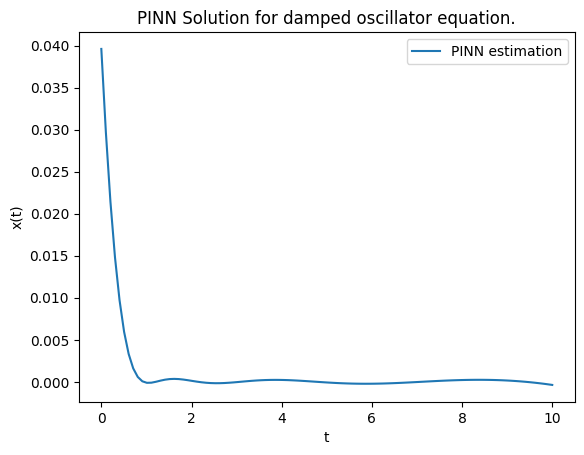

In [58]:
# Test the model
t_test = 10*torch.linspace(0, 1, 100).reshape(-1, 1)
x_test = model(t_test)

# Plot the results
import matplotlib.pyplot as plt
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()